# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Emma Chung

**Date:** 9/8/2026

# Your Phase 1 solution to the problem goes here.
Q1: Photos in github repo 

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

gifts = pd.read_csv("./data/ForeignGifts_edu.csv")

gifts.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [16]:
gifts.shape

(28221, 10)

In [17]:
gifts.dtypes

ID                             int64
OPEID                          int64
Institution Name              object
City                          object
State                         object
Foreign Gift Received Date     int64
Foreign Gift Amount            int64
Gift Type                     object
Country of Giftor             object
Giftor Name                   object
dtype: object

In [18]:
# look at summary statistics to see the distribution of gift amounts
gifts["Foreign Gift Amount"].describe()

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64

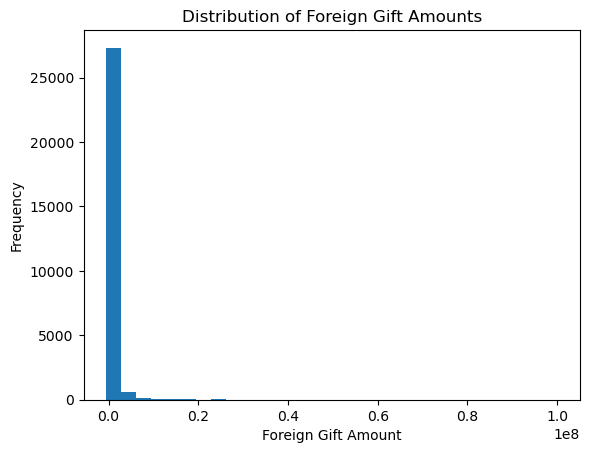

In [19]:
plt.hist(gifts["Foreign Gift Amount"], bins=30)

plt.xlabel("Foreign Gift Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Foreign Gift Amounts")

plt.show()

The Foreign Gift Amount variable is quantitative and has a strongly right-skewed distribution. The mean gift amount is about $588,233, while the median is only $94,615. The mean being much larger than the median shows that a small number of very large gifts may be pulling the mean upward. The maximum gift is about $100 million, which is much larger than most observations in the dataset. There are also some negative gift amounts, which may represent adjustments to previously reported amounts. Overall, most gifts are relatively small compared with a small number of extremely large gifts.

In [20]:
# count how often each gift type appears since Gift Type is categorical
gift_type_counts = gifts["Gift Type"].value_counts()
gift_type_counts

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

In [21]:
# calculate proportions to compare how much of the dataset each gift type represents
gift_type_proportions = gifts["Gift Type"].value_counts(normalize=True)
gift_type_proportions

Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64

There are three gift types in the dataset: contracts, monetary gifts, and real estate. Contracts make up approximately 61.2% of the observations, while monetary gifts make up approximately 38.8%. Real estate accounts for only about 0.04% of the observations. Therefore, contracts are the most common gift type in the dataset, followed by monetary gifts. Real estate gifts are rare.

In [22]:
# keep only positive gift amounts because the log is not defined for zero or negative values
positive_gifts = gifts[gifts["Foreign Gift Amount"] > 0].copy()

In [23]:
import numpy as np

positive_gifts["Log Gift Amount"] = np.log(
    positive_gifts["Foreign Gift Amount"]
)

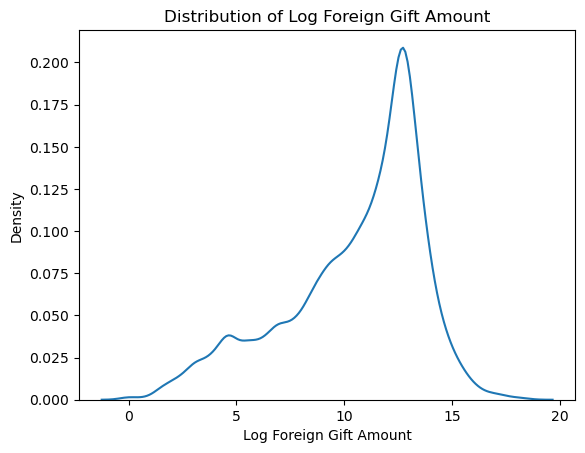

In [24]:
sns.kdeplot(data=positive_gifts, x="Log Gift Amount")

plt.xlabel("Log Foreign Gift Amount")
plt.title("Distribution of Log Foreign Gift Amount")

plt.show()

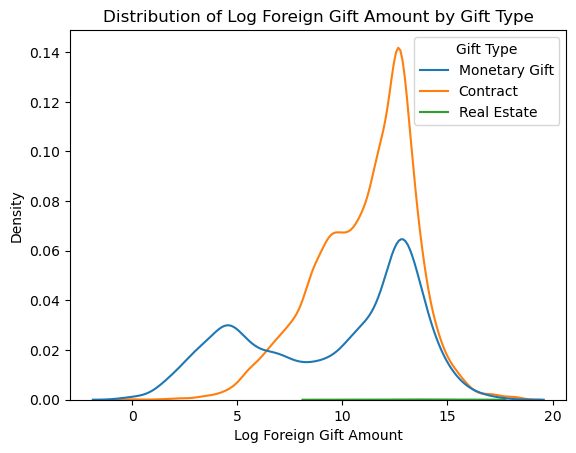

In [25]:
# separate the distributions by gift type to compare their gift amounts
sns.kdeplot(
    data=positive_gifts,
    x="Log Gift Amount",
    hue="Gift Type"
)

plt.xlabel("Log Foreign Gift Amount")
plt.title("Distribution of Log Foreign Gift Amount by Gift Type")

plt.show()

Taking the log of Foreign Gift Amount makes the distribution much less skewed to the right and makes it easier to see the overall pattern of gift amounts. When the distributions are separated by gift type, contracts and monetary gifts overlap, showing that their gift amounts are often in similar ranges. Real estate gifts appear to be concentrated at relatively larger amounts, although there are very few real estate observations in the dataset. Because there are only 11 real estate gifts, this distribution should be interpreted with caution.

In [26]:
top_countries_count = (
    gifts.groupby("Country of Giftor")
    .size()
    .sort_values(ascending=False)
    .head(15)
)

top_countries_count

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
dtype: int64

In [27]:
# sum the gift amounts by country to find which countries gave the most money overall
top_countries_amount = (
    gifts.groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_countries_amount

Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64

England has the largest number of reported gifts, followed by China, Canada, Japan, and Switzerland. However, ranking countries by the total amount given gives a different result. Qatar provides the largest total amount, at approximately $2.71 billion, followed by England, China, Saudi Arabia, and Bermuda. This shows that the countries providing the greatest number of gifts are not necessarily the countries providing the greatest total dollar amount. For example, Qatar does not have the most individual gifts, but its gifts have a very large total value.

In [28]:
# group by giftor and add their gift amounts to find the giftors that gave the most money, keeping similar giftor names separate because that is how they appear in the dataset
top_giftors = (
    gifts.groupby("Giftor Name")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_giftors

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64

The Qatar Foundation provides the largest total amount of money in the dataset, at approximately $1.17 billion. Other giftors with large total amounts include Qatar Foundation/Qatar National Res, Qatar Foundation for Education, Anonymous, and the Saudi Arabian Cultural Mission. The results show that some individual giftors account for very large amounts of foreign funding. Giftor names were kept exactly as they appear in the dataset, so organizations with similar names were treated as separate giftors. 

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [29]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]